# Imports

In [27]:
import os,time,sys,pickle
from matplotlib import pyplot as plt
import numpy as np
import copy
from scipy.optimize import leastsq
from scipy import ndimage

import multiprocess as multiprocessing # Because in an interactive environment, only the former allows pickling objects on `__main__`
import time
import queue

from common.baseclasses import AWA
from common.misc import flatten
from common import numerical_recipes as numrec

from EigenProbe import common
sys.modules['common'] = common # This hook allows to continue to load probe files that were previously saved under an older alias for `common`

import EigenProbe as EP # https://github.com/asmcleod/EigenProbe.git
from EigenProbe import RotationalMoM as RotMOM
from EigenProbe import ProbeSpectroscopy as PS
from EigenProbe import EigenInversion as EI
from EigenProbe import Materials as M

sys.modules['ProbeCavityEigenfields'] = EP # This hook allows to continue to load probe files that were previously saved under an older alias for `EigenProbe`

# Load our pre-built Predictor

In [2]:
probe_name = 'Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244'
IE = EP.load(probe_name, PS.InvertibleEigenfields, overwrite_probe=True)

a = IE.get_probe().get_a()
sim_kwargs=dict(zmin=a/10,A=4*a,Ngaps=24,harmonic=3)
eps_ref=-1e8

Predictor_S3_from_bulk = EI.InvertibleEigenfieldsPredictor(invertible_eigenfields=IE,
                                                           eps_ref = eps_ref, **sim_kwargs)

Attemping to load from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_InvertibleEigenfields.pickle"...
Attemping to load from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_Probe.pickle"...
<__init__._ProbesCollection.__setitem__>:
	Registering probe "Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244"...
Successfully loaded from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_Probe.pickle"!
Successfully loaded from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_InvertibleEigenfields.pickle"!


# Construct a ground truth permittivity and exemplary data

In [31]:
%matplotlib inline

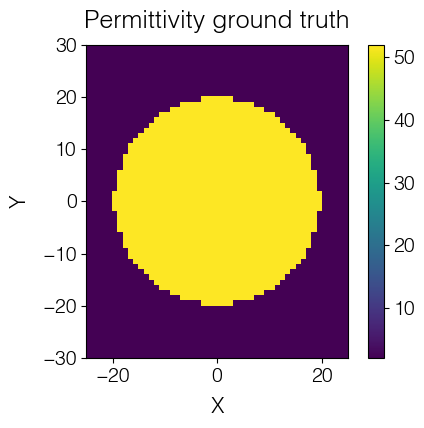

In [33]:
shape = (50,60)
sx,sy=shape
spot_size=20

xs = np.linspace(-sx/2,sx/2,sx)
ys = np.linspace(-sy/2,sy/2,sy)

Ys,Xs = np.meshgrid(ys,xs)
Rs2 = Xs**2+Ys**2
#deps_ground_truth = (5+1j)*np.exp(-Rs2/(2*spot_size))
deps_ground_truth = 10*(5+1j)*(Rs2<spot_size**2)
eps_ground_truth=2+deps_ground_truth

eps_ground_truth = AWA(eps_ground_truth,axes=[xs,ys],axis_names=['X','Y'])

plt.figure()
eps_ground_truth.real.plot()
plt.title('Permittivity ground truth')
plt.gca().set_aspect('equal')
plt.tight_layout()

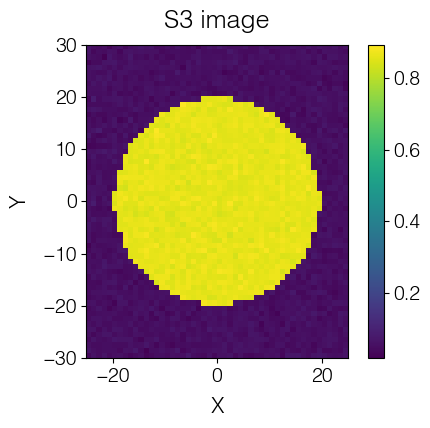

In [34]:
S3_data_image=np.zeros(shape)

for i in range(sx):
    for j in range(sy):
        eps_val = eps_ground_truth[i,j]
        S3_data_image[i,j] = Predictor_S3_from_bulk(eps = eps_val)

noise = 1e-2
S3_data_image += noise * np.random.randn(*shape)
S3_data_image = AWA(S3_data_image,adopt_axes_from = eps_ground_truth)

plt.figure()
S3_data_image.real.plot()
plt.title('S3 image')
plt.gca().set_aspect('equal')
plt.tight_layout()

# Define a worker who executes the recovery

In [89]:
def residual(params,*args):

    eps_real, eps_imag = params
    eps = eps_real + 1j * eps_imag
    S_target_real, S_target_imag, Predictor, qp, exp = args

    S_target = S_target_real + 1j * S_target_imag
    prediction = Predictor(qp=qp, eps=eps)

    to_minimize = [np.abs(np.real(prediction - S_target)) ** exp,
                   np.abs(np.imag(prediction - S_target)) ** exp]

    return to_minimize

eps_guesses_image = None

def recover_eps_at_pixel(i,j,S_target,eps_recovered_image,Predictor,
                         radius=None,exp=2,qp=None,eps_guess=1,
                         debug=False,
                        **leastsq_kwargs):
    # The goal is to recover a predictd permittivity associated to value `S_target`;
    # indices `i,j` provide situational awareness for guessing initial permittivity from values recovered at earlier pixels

    if debug: print('Target signal:',S_target)

    global eps_guesses_image,weight_gaussian
    if eps_guesses_image is None or eps_guesses_image.shape != eps_recovered_image.shape:
        if debug: print('Initializing image of guessed permittivities')
        eps_guesses_image = np.zeros(eps_recovered_image.shape,dtype=complex)
    
    where_known = np.isfinite(eps_recovered_image)
    
    if where_known.any():
        eps_guesses = eps_recovered_image[where_known]
        if radius is None:
            weight=1
        else:
            # Fast Gaussian builder
            g1 = np.exp(-(xs-xs[i])**2/(2*radius**2))
            g2 = np.exp(-(ys-ys[j])**2/(2*radius**2))
            weight_gaussian = np.outer(g1, g2)
            weight = weight_gaussian[where_known]

        eps_guess = np.sum(eps_guesses*weight)/np.sum(weight)

    eps_guesses_image[i,j] = eps_guess
    if debug: print('Guess eps:',eps_guess)

    x0 = (eps_guess.real,eps_guess.imag)
    args = S_target.real, S_target.imag, Predictor, qp, exp

    T=EP.Timer()
    result = leastsq(residual, x0, args=args,
                     **leastsq_kwargs)[0]
    eps_pred = result[0] + 1j * result[1]
    if debug:
        print('Recovered permittivity at pixel (%i,%i): eps = %s'%(i,j,eps_pred))
        print(T())

    eps_recovered_image[i,j]=eps_pred

    return eps_pred

# Demonstrate recover from an image in a for-loop

## Set up figures to monitor progress of the "experiment"

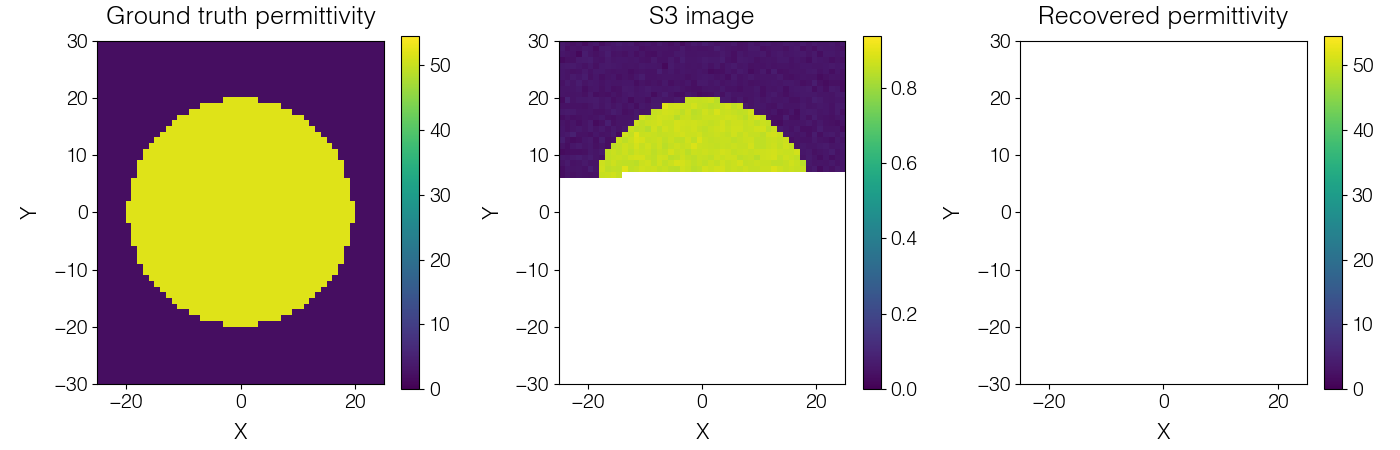

In [94]:
%matplotlib widget

eps_recovered_image = np.zeros(shape,dtype=complex)
eps_recovered_image[:] = np.nan
eps_recovered_image = AWA(eps_recovered_image,adopt_axes_from=S3_data_image)

fig = plt.figure(figsize=(14,4.5))
plt.style.use('fast')

plt.subplot(131)
eps_ground_truth.real.plot(colorbar=True)
plt.title('Ground truth permittivity')
plt.gca().set_aspect('equal')
plt.clim(0,1.05*eps_ground_truth.real.max())

plt.subplot(132)
im1 = S3_recorded_image.real.plot(colorbar=True)
plt.title('S3 image')
plt.gca().set_aspect('equal')
plt.clim(0,1.05*S3_data_image.real.max())

plt.subplot(133)
im2 = eps_recovered_image.real.plot(colorbar=True)
plt.title('Recovered permittivity')
plt.gca().set_aspect('equal')
plt.clim(0,1.05*eps_ground_truth.real.max())

plt.tight_layout()
fig.canvas.draw()

### An intentional interrupt

Be sure to pause execution of the notebook after the cell above, to let the canvas draw!

In [37]:
raise KeyboardInterrupt('Now you are ready to (manually) execute the experiment (below)')  # This interrupt is intentional, for the reason above.

KeyboardInterrupt: 

## Execute the experiment

In [95]:
#--- Reset the recorded and recovered images
S3_recorded_image = np.zeros(shape,dtype=complex)
S3_recorded_image[:] = np.nan
S3_recorded_image = AWA(S3_recorded_image,adopt_axes_from=S3_data_image)

eps_recovered_image = np.zeros(shape,dtype=complex)
eps_recovered_image[:] = np.nan
eps_recovered_image = AWA(eps_recovered_image,adopt_axes_from=S3_data_image)

plot_interval=20

leastsq_kwargs = dict(maxfev=100)

for j in range(sy):
    ind2 = -j-1
    for i in range(sx):
        ind1 = i
        S3_target = S3_data_image[ind1,ind2]
        S3_recorded_image[ind1,ind2] = S3_target
        recover_eps_at_pixel(ind1,ind2,S3_target,eps_recovered_image,Predictor=Predictor_S3_from_bulk,
                            radius=5,exp=2,qp=None,
                             **leastsq_kwargs)
        
        if not i%plot_interval:
            im1.set_data(np.array(S3_recorded_image.real).T)
            im2.set_data(np.array(eps_recovered_image.real).T)
            fig.canvas.draw()

im1.set_data(np.array(S3_recorded_image.real).T)
im2.set_data(np.array(eps_recovered_image.real).T)
fig.canvas.draw()

#  Asynchronously (Record data) + (Recover permittivity): Consumer + Producter implementation

## Define the producer and consumer

In [50]:
def Producer(signal_output_to_recover, signal_output_to_image, S3_data_image, pixel_time=5e-3):
    # This places (i,j,S3_val) into two queues: one read by the recovery tool, and the other read to populate an image

    shape = S3_data_image.shape
    S3_data_flattened = S3_data_image.flatten()
    
    for flat_index,S3_val in enumerate(S3_data_flattened):

        i,j = np.unravel_index(flat_index, shape)
        time.sleep(pixel_time)  # Simulate work

        item_out = (i,j,S3_val)
        signal_output_to_recover.put(item_out)
        signal_output_to_image.put(item_out)
        
    # Send a sentinel value (None) to signal completion
    signal_output_to_recover.put(None)
    signal_output_to_image.put(None)
    
    print('\nProducer has finished generating data.\n',flush=True,end='\r')

def Consumer(take_from_signal_queue, put_into_recovered_queue,
             im_shape, Predictor,
             kwargs):
    # This places (i,j,eps_val) into a queue, to populate an image of recovered permittivities
    # kwargs may include `radius`, `exp`, `qp`,`eps_guess`, and other keywords for `leastsq`

    # An (entirely) local record of all recovered values so far.  This image allows to update starting guess permittivities.
    eps_recovered_image = np.zeros(im_shape,dtype=complex)
    eps_recovered_image[:] = np.nan

    while True:
        # get() blocks by default until an item is available
        item_int = take_from_signal_queue.get()
        
        # Check for the sentinel value to break the loop
        if item_int is None:
            put_into_recovered_queue.put(None)
            print("\nConsumer has finished processing recorded data.")
            break
            
        i,j,S3_target = item_int
        eps_val = recover_eps_at_pixel(i,j,S3_target,eps_recovered_image,Predictor,
                                                   **kwargs) # THis will populate `eps_recovered_image` for internal use
        item_out = (i,j,eps_val)
        put_into_recovered_queue.put(item_out)

        #time.sleep(10e-3) # Add this line to artificially slow down the recovery step, to see how the workflow behaves when the consumer is rate-limiting.
        
    print('Consumer closed.\n',flush=True,end='\r')

## Define the experiment

In [199]:
def run_producer_consumer_experiment(pixel_time=1e-3, loop_interval = 1e-3,plot_interval=200e-3,eps_guess=1):
    # This function invokes a lot of global parameters.    

    #--- Set up the Producer
    
    shared_queue = multiprocessing.Queue()
    signal_queue = multiprocessing.Queue()
    producer_args = (shared_queue, # queue where producer will drop target signal values for consumer
                     signal_queue,  # queue where producer will drop target signal values for populating image
                     S3_data_image, # The data that the producer is intended to 'regurgitate' pixel-by-pixel, as emitted from a real experiment
                     pixel_time) # Time per pixel (emission of a new signal value)
    p1 = multiprocessing.Process(target=Producer, args=producer_args)
    
    # --- Set up the Consumer
    consumer_kwargs=dict(radius=10,exp=2,qp=None,eps_guess=eps_guess,debug=False) # `radius` is the pixel range from inside of which producer will make a guess at permittivity
    leastsq_kwargs={} # Could put `maxfev` etc. to control how `leastsq` operates
    consumer_kwargs.update(leastsq_kwargs)
    
    recovered_queue = multiprocessing.Queue()
    consumer_args=(shared_queue, # queue from which consumer will draw target signal values
                   recovered_queue, # queue where consumer will put recovered permittivity values
                   eps_recovered_image.shape, # image shape gives the consumer situational awareness for guessing permittivity from what's known within `radius`
                   Predictor_S3_from_bulk, # Out fast predictor: eps --> S3
                   consumer_kwargs) # arguments for the nonlinear least-squares fitting
    p2 = multiprocessing.Process(target=Consumer, args=consumer_args)
    
    
    # ---- Now, setup is done, let the games begin!
    
    # --- Star the consumer/producer
    p1.start()
    p2.start()
    
    # --- Start the monitor loop
    # Begin drawing outputs from both both producer and consumer, and updating the plots above, at intervals
    loop_iteration=0
    producer_done=False
    consumer_done=False
    producer_time=consumer_time=0
    producer_interval=consumer_interval=0
    i_record=j_record=0
    while True:
    
        if not loop_iteration % int(plot_interval/loop_interval): do_update_plot=True
        else: do_update_plot=False
    
        # --- Try to get a signal from producer
        try:
            #if not np.isnan(S3_recorded_image).any(): # No more data to get from queue!
            #    producer_done=True
            #    raise queue.Empty 
                
            item  = signal_queue.get(block=False) # If queue is empty, move on
            if item is None:
                producer_done=True
                raise queue.Empty
    
            # Figure out how long the producer took to produce a new value
            t=time.time()
            producer_interval = (t-producer_time)*1e3
            producer_time=t
    
            # Good signal value, put it in our recorded image
            i_record,j_record,S3_val = item
            S3_recorded_image[i_record,j_record]=S3_val
            
        except queue.Empty: pass
    
        # --- Try to get a recovered value from consumer
        try:
                
            item  = recovered_queue.get(block=False) # If queue is empty, move on
            if item is None:
                consumer_done=True
                raise queue.Empty
            
            # Figure out how long the consumer took to produce a new value
            t=time.time()
            consumer_interval = (t-consumer_time)*1e3
            consumer_time=t
    
            # Good eps value, put it in our recovered image
            i_recov,j_recov,eps_val = item
            eps_recovered_image[i_recov,j_recov]=eps_val
            
        except queue.Empty: pass
            
        # --- Update plot of recorded signals
        if do_update_plot: update_plots(i=i_record,j=j_record)
    
        # --- Print the average time
        print_str = 'Time to record a signal (ms): %1.2f \t Time to recover a permittivity (ms): %1.2f'%(producer_interval,consumer_interval)
        print(f"{print_str:<100}", end="\r", flush=True) # This jazz adds white space to cover previously printed lines completely.
        time.sleep(loop_interval)
        loop_iteration +=1 # Every `plot_interval` we will re-plot
            
        if producer_done and consumer_done:
            print('\nBoth consumer and producer are done!',flush=True)
            break
    
    update_plots(i=i_record,j=j_record)
        
    p1.join()
    p2.join()
    print("All processes have completed successfully.")

## Put it to the test

### Set up figures to monitor the experiment

/usr/local/Cellar/micromamba/2.8.1/envs/EigenProbe/lib/python3.9/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


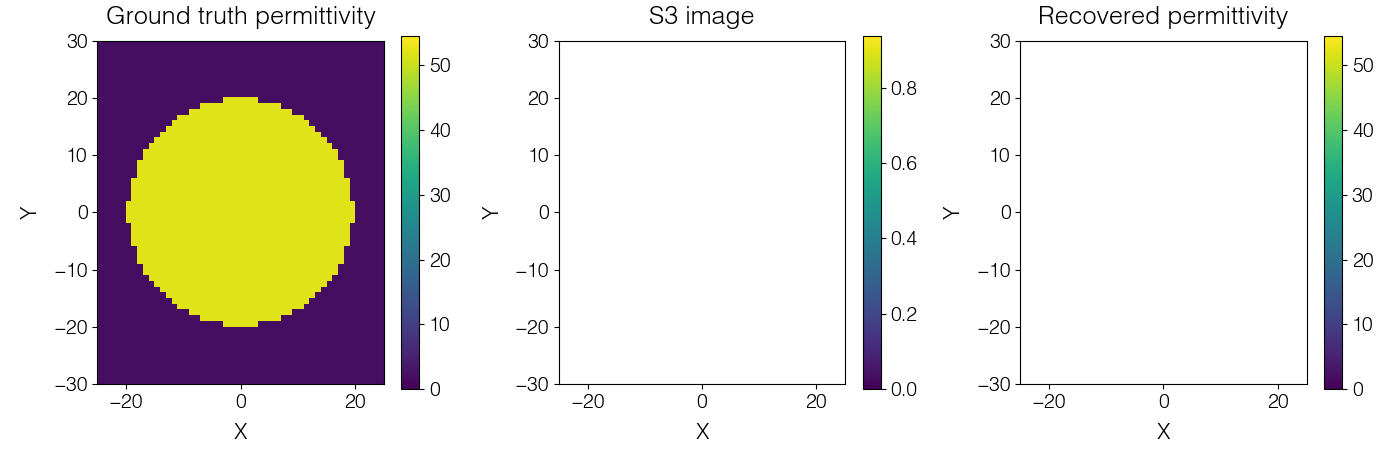

In [52]:
%matplotlib widget

S3_recorded_image = np.zeros(shape,dtype=complex)
S3_recorded_image[:] = np.nan
S3_recorded_image = AWA(S3_recorded_image,adopt_axes_from=S3_data_image)

eps_recovered_image = np.zeros(shape,dtype=complex)
eps_recovered_image[:] = np.nan
eps_recovered_image = AWA(eps_recovered_image,adopt_axes_from=S3_data_image)

fig = plt.figure(figsize=(14,4.5))
plt.style.use('fast')

plt.subplot(131)
eps_ground_truth.real.plot(colorbar=True)
plt.title('Ground truth permittivity')
plt.gca().set_aspect('equal')
plt.clim(0,1.05*eps_ground_truth.real.max())

plt.subplot(132)
im1 = S3_recorded_image.real.plot(colorbar=True)
plt.title('S3 image')
plt.gca().set_aspect('equal')
plt.clim(0,1.05*S3_data_image.real.max())

plt.subplot(133)
im2 = eps_recovered_image.real.plot(colorbar=True)
plt.title('Recovered permittivity')
plt.gca().set_aspect('equal')
plt.clim(0,1.05*eps_ground_truth.real.max())

plt.tight_layout()
fig.canvas.draw()

def update_plots():
    
    im1.set_data(np.array(S3_recorded_image.real).T)
    im2.set_data(np.array(eps_recovered_image.real).T)
    fig.canvas.draw()


#### An intentional interrupt

Be sure to pause execution of the notebook after the cell above, to let the canvas draw!

In [53]:
raise KeyboardInterrupt('Now you are ready to (manually) execute the experiment (below)') # This interrupt is intentional, for the reason above.

KeyboardInterrupt: 

### Execute the experiment - watch it populate the figures above!

In [54]:
# This is the ground-truth data which hopefully the recovered permittivity will well describe
eps_ground_truth;

# This is the array from which "data values" will be drawn
S3_data_image;

# These arrays will be populated during the experiment:
S3_recorded_image; 
eps_recovered_image;

# These are the plot entities that will be dynamically updated:
im1; im2; fig;

pixel_time = 5e-3 # A typical experiment has several-millisecond pixels.  Let's see if the recovery process can keep up!
run_producer_consumer_experiment( pixel_time=pixel_time, loop_interval = 1e-3, plot_interval=100e-3 )

Time to record a signal (ms): 1.89 	 Time to recover a permittivity (ms): 5.06                      
Producer has finished generating data.
Time to record a signal (ms): 2.10 	 Time to recover a permittivity (ms): 1.66                      
Consumer has finished processing recorded data.
Consumer closed. signal (ms): 2.10 	 Time to recover a permittivity (ms): 1.76                      
Time to record a signal (ms): 2.10 	 Time to recover a permittivity (ms): 1.84                      
Both consumer and producer are done!
All processes have completed successfully.


# Test on real data

In [97]:
ls "Example Data"

P3.gwy  P3.png  P3.txt  S3.gwy  S3.png  S3.txt


## Load data

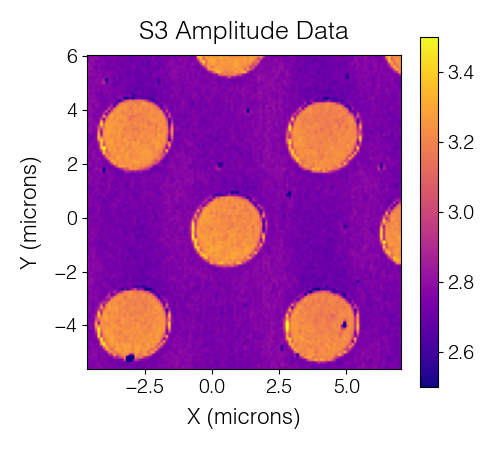

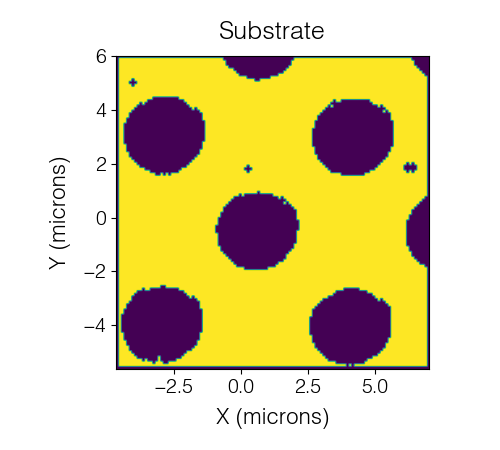

In [236]:
p3 = np.loadtxt('Example Data/P3.txt')
s3 = np.loadtxt('Example Data/S3.txt')

#downsampling=1.6
#p3 = ndimage.zoom(p3, zoom=1/downsampling, order=3)
#s3 = ndimage.zoom(s3, zoom=1/downsampling, order=3)

shape = s3.shape
sx,sy=shape

xs = np.linspace(-sx/2,sx/2,sx)*25/sx
ys = np.linspace(-sy/2,sy/2,sy)*25/sx

S3_data_image = s3*np.exp(1j*p3)
S3_data_image = AWA(S3_data_image,axes=[xs,ys],axis_names=['X (microns)','Y (microns)'])

keep_size=120;dx=80;dy=70
S3_data_image=S3_data_image[dx:dx+keep_size,dy:dy+keep_size]
xs,ys = S3_data_image.axes
shape = S3_data_image.shape

plt.figure()
np.abs(S3_data_image).plot(cmap='plasma')
plt.clim(2.5,3.5)
plt.gca().set_aspect('equal')
plt.title('S3 Amplitude Data')
plt.tight_layout()

Si_substrate = np.abs(S3_data_image)<2.85
Si_substrate = ndimage.binary_erosion(Si_substrate)
Si_substrate = AWA(Si_substrate,adopt_axes_from=S3_data_image)

plt.figure()
Si_substrate.plot(alpha=1,colorbar=False)
plt.gca().set_aspect('equal')
plt.title('Substrate')
plt.tight_layout()

S3_data_image/=np.mean(S3_data_image[Si_substrate])

eps_ground_truth = S3_data_image

## Set up Predictor

In [181]:
probe_name = 'Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244'
IE = EP.load(probe_name, PS.InvertibleEigenfields, overwrite_probe=True)

a = IE.get_probe().get_a()
sim_kwargs=dict(zmin=a/10,A=4*a,Ngaps=24,harmonic=3)

eps_Si=M.Si.epsilon(1000)
eps_ref=eps_Si # permittivity of silicon

Predictor_S3_from_bulk = EI.InvertibleEigenfieldsPredictor(invertible_eigenfields=IE,
                                                           eps_ref = eps_ref, **sim_kwargs)

Attemping to load from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_InvertibleEigenfields.pickle"...
Attemping to load from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_Probe.pickle"...
<EigenProbe._ProbesCollection.__setitem__>:
	Overwriting registered probe "Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244"...
Successfully loaded from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_Probe.pickle"!
Successfully loaded from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_InvertibleEigenfields.pickle"!


## Set up figures to monitor progress of the "experiment"

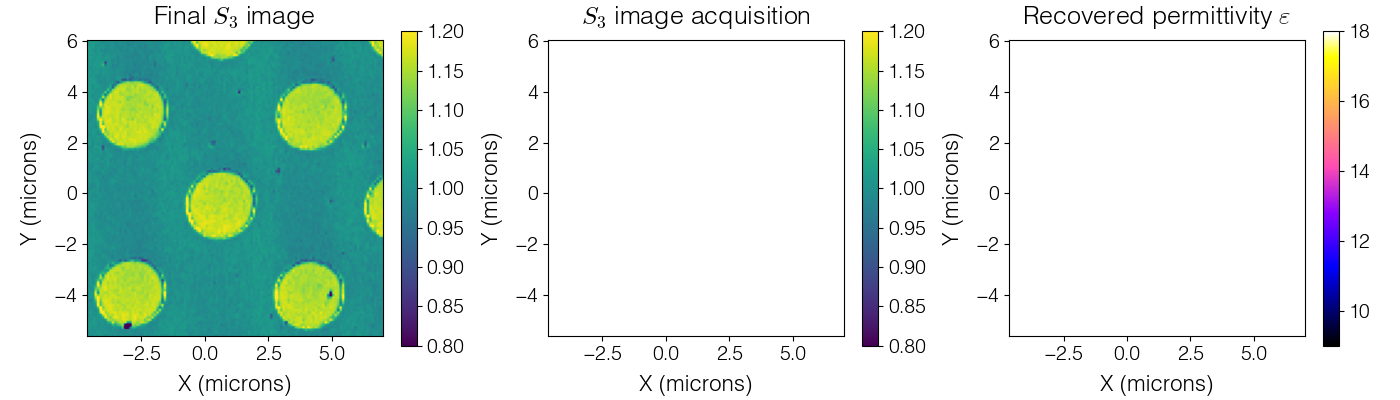

In [237]:
%matplotlib widget

S3_recorded_image = np.zeros(shape,dtype=complex)
S3_recorded_image[:] = np.nan
S3_recorded_image = AWA(S3_recorded_image,adopt_axes_from=S3_data_image)

eps_recovered_image = np.zeros(shape,dtype=complex)
eps_recovered_image[:] = np.nan
eps_recovered_image = AWA(eps_recovered_image,adopt_axes_from=S3_data_image)

fig = plt.figure(figsize=(14,4))
#plt.style.use('fast')

plt.subplot(131)
eps_ground_truth.real.plot(colorbar=True)
plt.title(r'Final $S_3$ image')
plt.gca().set_aspect('equal')
plt.clim(.8,1.2)

plt.subplot(132)
im1 = S3_recorded_image.real.plot(colorbar=True,vmin=.8,vmax=1.2)
plt.title(r'$S_3$ image acquisition')
plt.gca().set_aspect('equal')

plt.subplot(133)
im2 = eps_recovered_image.real.plot(colorbar=True,vmin=9, vmax=18,cmap='gnuplot2') 
plt.title(r'Recovered permittivity $\varepsilon$')
plt.gca().set_aspect('equal')

plt.tight_layout()
fig.canvas.draw()

im_index=0
save_imgs = True

def update_plots(i=None,j=None):

    im1.set_data(np.array(S3_recorded_image.real).T)
    im2.set_data(np.array(eps_recovered_image.real).T)

    # Plot a marker where the probe is
    if i is not None and j is not None:
        ax = im1.axes
        while ax.lines: ax.lines[0].remove()
        ax.plot(xs[i],ys[j],marker='v',color=(.3,.3,1),ms=10,markeredgecolor='w')
        ax = im2.axes
        while ax.lines: ax.lines[0].remove()
        ax.plot(xs[i],ys[j],marker='v',color=(.3,.3,1),ms=10,markeredgecolor='w')
        
    fig.canvas.draw()
    
    if save_imgs:
        global im_index
        num = f"{im_index:06d}"
        plt.savefig('Imgs/'+num+'.png',dpi=300)
        im_index+=1


### An intentional interrupt

Be sure to pause execution of the notebook after the cell above, to let the canvas draw!

In [37]:
raise KeyboardInterrupt('Now you are ready to (manually) execute the experiment (below)')  # This interrupt is intentional, for the reason above.

KeyboardInterrupt: 

## Execute the experiment

In [238]:
# This is the ground-truth data which hopefully the recovered permittivity will well describe
eps_ground_truth;

# This is the array from which "data values" will be drawn
S3_data_image;

# These arrays will be populated during the experiment:
S3_recorded_image; 
eps_recovered_image;

# These are the plot entities that will be dynamically updated:
im1; im2; fig;

pixel_time = 10e-3 # A typical experiment has several-millisecond pixels.  Let's see if the recovery process can keep up!
run_producer_consumer_experiment( pixel_time=pixel_time, loop_interval = 1e-3, plot_interval=10e-3, eps_guess = eps_ref)

remaking
Time to record a signal (ms): 1.83 	 Time to recover a permittivity (ms): 1.80                      63
Producer has finished generating data.

Consumer has finished processing recorded data.
Consumer closed.
Time to record a signal (ms): 1.98 	 Time to recover a permittivity (ms): 1.99                      
Both consumer and producer are done!
All processes have completed successfully.


In [217]:
mkdir Imgs